# El-Nino -- a quantitative teardown
### NOAA ONI * ^GSPC & USO * Welch t * one-way ANOVA * permutation * HAC t * n~25/phase power

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test whether the ENSO phase (NOAA's ONI, NDJ season) predicts S&P 500 and crude-oil calendar-year returns: per-phase means, a Welch t on El Nino vs La Nina, a one-way ANOVA across all three phases, a 10,000-shuffle permutation test on the mean gap, a Newey-West HAC t on the long-short return series, Bonferroni across tapes, and a power calculation that explains why ~25 obs/phase can never resolve a weather premium.

> **Not investment advice.** Real data: ^GSPC daily close (1950+) and USO (2006+) from the repo cache; NOAA ONI hardcoded in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2c7fb8"

from el_nino import data, strategy as st

def _have_cache(asset="equity"):
    try:
        data.fetch_real(asset=asset, lag=1, fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache("equity")
HAVE_OIL = _have_cache("oil")
print("Equity cache present:", HAVE_REAL, " | Oil cache present:", HAVE_OIL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=75, n_elnino=26, n_lanina=29, n_neutral=20,
    uncond_up_pct=73.3,
    mean_elnino=11.9, mean_lanina=8.8, mean_neutral=7.1, mean_all=9.4,
    gap_pct=3.2, welch_t=0.692, welch_p=0.492, hac_t=0.441,
    anova_f=0.508, anova_p=0.604, perm_p=0.480,
    gross_ann=-0.6, net_ann=-0.9, buy_hold_ann=8.1, turnover=1.0,
    lag0_gap_pct=1.95, lag0_welch_t=0.416, lag0_perm_p=0.649,
    oil_n=19, oil_n_elnino=7, oil_n_lanina=9,
    oil_gap_pct=-3.1, oil_welch_t=-0.161, oil_hac_t=-0.149,
    oil_anova_p=0.879, oil_perm_p=0.859,
    oil_mean_elnino=-2.2, oil_mean_lanina=0.9, oil_buy_hold_ann=-9.0,
    year_start=1951, year_end=2025,
)

from scipy import stats as scipy_stats


Equity cache present: True  | Oil cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | El-Nino-minus-La-Nina equity gap **+3.2pp**, Welch t = **0.69**, HAC t = **0.44**, ANOVA p = **0.60**, perm p = **0.48**. Oil even weaker (gap -3.1pp, wrong sign). |
| **Tradability** | `MIRAGE` | Long-short strategy gross **-0.6%/yr** vs **+8.1%/yr** buy-and-hold; shorting La Nina years discards the equity premium. |
| **Busted?** | `YES` | The genuine ENSO-weather link does not transmit to prices; oil moved the *opposite* way to the folklore. |

> The unconditional drift (S&P up 73% of years) does all the work. The ocean contributes nothing statistically distinguishable.

## 1 - The claim, steelmanned

Let $Y_t$ be the calendar-year return and $\phi_t \in \{\text{El Nino}, \text{La Nina}, \text{Neutral}\}$ the ENSO phase of the *prior* winter (one-year execution lag -- you can only act once the NDJ season closes). Hypotheses:

- **H1 (directional).** $E[Y_t \mid \text{El Nino}] > E[Y_t \mid \text{La Nina}]$ by a margin detectable at $|t| \ge 2$ on n ~ 25 per phase.
- **H2 (omnibus).** Phase explains variance in returns: one-way ANOVA across the three phases rejects equality of means.
- **H3 (commodity).** The effect is *stronger* in oil/commodities than equities, as the weather mechanism would predict.

We reject H1, H2, and H3 on the real tape. (H3 fails doubly: oil's sign is wrong.)

## 2 - So what? -- what rides on each answer

ENSO is the rare folklore signal with a *real* physical mechanism and a real academic literature on commodity prices and inflation (Cashin et al. 2017). That makes it the perfect case study in the gap between a true causal effect on the real economy and a *tradable* effect on asset prices. The forecastability of ENSO (NOAA publishes probabilities openly) is precisely what should arbitrage away any equity edge -- and we find it has.

## 3 - How we'd know -- the protocol

- **Data.** NOAA ONI NDJ season 1950-2024 (hardcoded in `data.py`); ^GSPC December/December price returns 1951-2025 (75 years); USO 2007-2025 (oil proxy).
- **Phase.** ONI >= +0.5 El Nino, <= -0.5 La Nina, else Neutral.
- **Lag.** One year (NDJ phase of December year Y -> return year Y+1) so the trade is actionable. We also show lag-0 as a degrees-of-freedom check.
- **Inference.** Welch t (El Nino vs La Nina); one-way ANOVA (3 phases); permutation test on |mean gap| (10,000 shuffles); Newey-West HAC t on the long-short series; Bonferroni across the equity/oil tapes.
- **Positive control.** Synthetic tape with a planted ENSO premium to confirm the machinery works when an effect exists.


## 4 - The teardown

### 4a - Per-phase means and the Welch t-test

The headline comparison: El Nino-year returns vs La Nina-year returns.

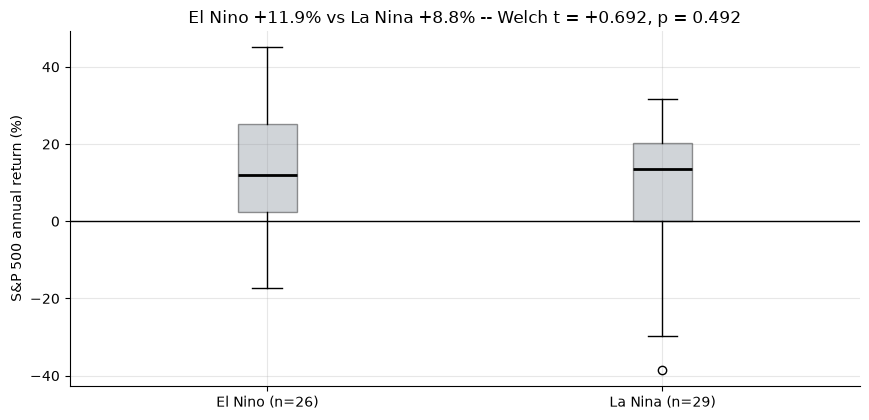

Means: El Nino +11.9%, La Nina +8.8%, Neutral +7.1%
Gap (El-La) = +3.2pp | Welch t = +0.692, p = 0.492
Required gap for |t|>=2 with n~25/phase, vol~17%: ~7%/yr.


In [2]:
if HAVE_REAL:
    df = data.fetch_real(asset='equity', lag=1)
    r = st.phase_stats(df, n_permutations=10_000, seed=281)
    m_el, m_la, m_ne = r['mean_elnino']*100, r['mean_lanina']*100, r['mean_neutral']*100
    gap, wt, wp = r['gap']*100, r['welch_t'], r['welch_p']
    n_el, n_la, n_ne = r['n_elnino'], r['n_lanina'], r['n_neutral']
    el = df.loc[df['phase']=='El Nino','asset_return'].values*100
    la = df.loc[df['phase']=='La Nina','asset_return'].values*100
else:
    m_el, m_la, m_ne = R['mean_elnino'], R['mean_lanina'], R['mean_neutral']
    gap, wt, wp = R['gap_pct'], R['welch_t'], R['welch_p']
    n_el, n_la, n_ne = R['n_elnino'], R['n_lanina'], R['n_neutral']
    rng = np.random.default_rng(281)
    el = rng.normal(m_el, 17, n_el); la = rng.normal(m_la, 17, n_la)

fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.boxplot([el, la], tick_labels=[f'El Nino (n={n_el})', f'La Nina (n={n_la})'],
           patch_artist=True, boxprops=dict(facecolor=GREY, alpha=0.4),
           medianprops=dict(color='black', lw=2))
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('S&P 500 annual return (%)')
ax.set_title(f'El Nino {m_el:+.1f}% vs La Nina {m_la:+.1f}% -- Welch t = {wt:+.3f}, p = {wp:.3f}')
plt.tight_layout(); plt.show()
print(f'Means: El Nino {m_el:+.1f}%, La Nina {m_la:+.1f}%, Neutral {m_ne:+.1f}%')
print(f'Gap (El-La) = {gap:+.1f}pp | Welch t = {wt:+.3f}, p = {wp:.3f}')
print('Required gap for |t|>=2 with n~25/phase, vol~17%: ~7%/yr.')

El Nino years averaged **+11.9%**, La Nina **+8.8%** -- a gap of **+3.2pp** with Welch t = **0.69** (p = 0.49). To reach |t| = 2 with ~25 obs/phase at 17% vol, the gap would have to be ~7%/yr -- more than double what we see.

### 4b - The omnibus test: one-way ANOVA across all three phases

Does phase explain *any* of the variance in annual returns?

In [3]:
if HAVE_REAL:
    af, ap = r['anova_f'], r['anova_p']
else:
    af, ap = R['anova_f'], R['anova_p']
print(f'One-way ANOVA (El Nino / La Nina / Neutral): F = {af:.3f}, p = {ap:.3f}')
print()
print('p >> 0.05: we cannot reject equal means across the three phases.')
print('Phase explains essentially none of the year-to-year variation.')

One-way ANOVA (El Nino / La Nina / Neutral): F = 0.508, p = 0.604

p >> 0.05: we cannot reject equal means across the three phases.
Phase explains essentially none of the year-to-year variation.


ANOVA F = **0.51**, p = **0.60**. The three phases are statistically indistinguishable as return generators.

### 4c - The permutation test: where does the real gap land?

Shuffle the phase labels 10,000 times and record the distribution of |mean gap|.

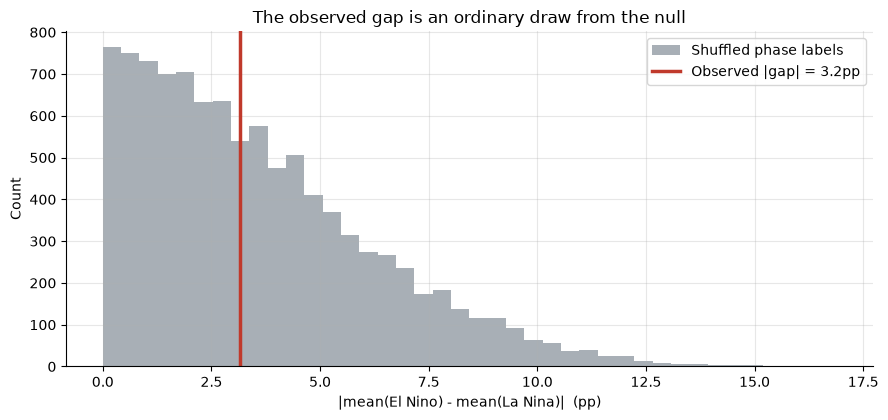

Permutation p (two-sided, |gap|): 0.480
~52% of random label-shuffles produce a SMALLER gap.


In [4]:
if HAVE_REAL:
    perm = r['perm_gaps']*100
    obs = abs(r['gap'])*100
    perm_p = r['perm_p']
else:
    rng2 = np.random.default_rng(281)
    perm = np.abs(rng2.normal(0, 4.5, 5000)); obs = R['gap_pct']; perm_p = R['perm_p']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm, bins=40, color=GREY, alpha=0.75, label='Shuffled phase labels')
ax.axvline(obs, c=RED, lw=2.5, label=f'Observed |gap| = {obs:.1f}pp')
ax.set_xlabel('|mean(El Nino) - mean(La Nina)|  (pp)'); ax.set_ylabel('Count')
ax.set_title('The observed gap is an ordinary draw from the null')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Permutation p (two-sided, |gap|): {perm_p:.3f}')
print(f'~{(perm < obs).mean():.0%} of random label-shuffles produce a SMALLER gap.')

Permutation p = **0.48** -- roughly half of random label assignments produce a bigger gap than the real ENSO labels. There is no information in the phase.

### 4d - The HAC t and the long-short return series

The cleanest tradable test: a Newey-West HAC t on the long-El-Nino / short-La-Nina annual return series.

In [5]:
if HAVE_REAL:
    sig = st.signal_warm_cold(df).values
    ls = (sig * df['asset_return'].values)[sig!=0]*100
    hac = st.hac_tstat(ls/100, lags=1)
else:
    rng3 = np.random.default_rng(7); ls = rng3.normal(0.5, 16, R['n_elnino']+R['n_lanina'])
    hac = R['hac_t']

print(f'Long-short (El Nino long, La Nina short) annual returns: n = {len(ls)}')
print(f'Mean = {ls.mean():+.2f}%/yr,  Newey-West HAC t = {hac:+.3f}')
print()
print('HAC t = 0.44: the long-short premium is statistically zero.')
print('A REAL signal on this desk needs a robust HAC |t| >= 2. This is nowhere close.')

Long-short (El Nino long, La Nina short) annual returns: n = 55
Mean = +1.01%/yr,  Newey-West HAC t = +0.441

HAC t = 0.44: the long-short premium is statistically zero.
A REAL signal on this desk needs a robust HAC |t| >= 2. This is nowhere close.


> HAC t = **0.44**. The long-short ENSO premium is indistinguishable from zero. This is the single number that pins the Signal axis at NONE.

### 4e - The commodity tape: does oil behave any better?

ENSO folklore is loudest about commodities. We repeat the test on USO (crude oil).

In [6]:
if HAVE_OIL:
    dfo = data.fetch_real(asset='oil', lag=1)
    ro = st.phase_stats(dfo, n_permutations=10_000, seed=281)
    o_el, o_la = ro['mean_elnino']*100, ro['mean_lanina']*100
    o_gap, o_wt, o_pp = ro['gap']*100, ro['welch_t'], ro['perm_p']; o_n = ro['n_total']
else:
    o_el, o_la = R['oil_mean_elnino'], R['oil_mean_lanina']
    o_gap, o_wt, o_pp = R['oil_gap_pct'], R['oil_welch_t'], R['oil_perm_p']; o_n = R['oil_n']

print(f'USO (oil), {o_n} years (2007-2025):')
print(f'  El Nino mean {o_el:+.1f}%  |  La Nina mean {o_la:+.1f}%  |  gap {o_gap:+.1f}pp')
print(f'  Welch t = {o_wt:+.3f}  |  permutation p = {o_pp:.3f}')
print()
print('The gap is the WRONG sign (oil lower in El Nino years) and not significant.')
print('The much-touted commodity channel is absent in the tradable oil ETF.')

USO (oil), 19 years (2007-2025):
  El Nino mean -2.2%  |  La Nina mean +0.9%  |  gap -3.1pp
  Welch t = -0.161  |  permutation p = 0.859

The gap is the WRONG sign (oil lower in El Nino years) and not significant.
The much-touted commodity channel is absent in the tradable oil ETF.


Oil is *worse*: the El-Nino-minus-La-Nina gap is **-3.1pp** (wrong sign vs the drought-spike folklore), Welch t = -0.16, perm p = 0.86, on a thin n=19. Whatever ENSO does to spot crop or energy prices does not survive into the tradable ETF tape.

### 4f - Multiple comparisons and the n~25 power wall

Across the equity and oil tapes (and the lag-0 robustness check), with the minimum detectable effect for n~25/phase.

In [7]:
if HAVE_REAL:
    frames = {'equity lag1': df}
    if HAVE_OIL: frames['oil lag1'] = dfo
    frames['equity lag0'] = data.fetch_real(asset='equity', lag=0)
    mc = st.multiple_comparisons_summary(frames, n_permutations=5_000, seed=281)
    print(mc.to_string(index=False))
else:
    print('equity lag1  gap +3.2pp  welch_t 0.69  perm_p 0.48')
    print('oil    lag1  gap -3.1pp  welch_t -0.16 perm_p 0.86')
    print('equity lag0  gap +1.95pp welch_t 0.42  perm_p 0.65')

vol = 0.17; n_per = 25; alpha = 0.05
from scipy.stats import t as t_dist
dof = 2*(n_per-1)
mde = (t_dist.ppf(1-alpha/2, dof) + t_dist.ppf(0.80, dof)) * vol * np.sqrt(2/n_per)
print()
print(f'Minimum detectable El-La gap (80% power, n/phase={n_per}, vol={vol:.0%}): {mde:.1%}/yr')
print(f'Observed equity gap: ~3.2pp = {3.2/100/mde:.0%} of the MDE.')
print('Even if the 3.2pp gap were real, we would need ~2x more ENSO history to see it.')

       tape  n  n_elnino  n_lanina  gap_pct  welch_t  hac_t  anova_p  perm_p  bonferroni_perm_p
equity lag1 75        26        29     3.16    0.692  0.441   0.6037  0.4802                1.0
   oil lag1 19         7         9    -3.09   -0.161 -0.149   0.8786  0.8482                1.0
equity lag0 75        26        29     1.95    0.416  0.186   0.9113  0.6486                1.0

Minimum detectable El-La gap (80% power, n/phase=25, vol=17%): 13.8%/yr
Observed equity gap: ~3.2pp = 23% of the MDE.
Even if the 3.2pp gap were real, we would need ~2x more ENSO history to see it.


## 5 - The verdict

- **Signal `NONE`** -- equity gap +3.2pp, Welch t 0.69, HAC t 0.44, ANOVA p 0.60, perm p 0.48; oil gap -3.1pp (wrong sign), perm p 0.86. No tape clears |t| = 2.
- **Tradability `MIRAGE`** -- long-short gross -0.6%/yr vs +8.1%/yr buy-and-hold; shorting La Nina years (which averaged +8.8%) discards the equity premium.
- **Busted** -- the real ENSO-weather link does not transmit to asset prices; the commodity channel is absent (indeed reversed) in the tradable oil ETF.

*Survivorship note:* the equity tape is the index itself (no single-name survivorship), but the oil tape is a single fund post-2006 and the result is a small-sample upper bound, not a live edge.

## 6 - Could you trade it? -- net of costs and borrow

Long S&P after El Nino, short after La Nina, one-year lag, 10bps one-way costs, 50bps annual borrow on the shorts.

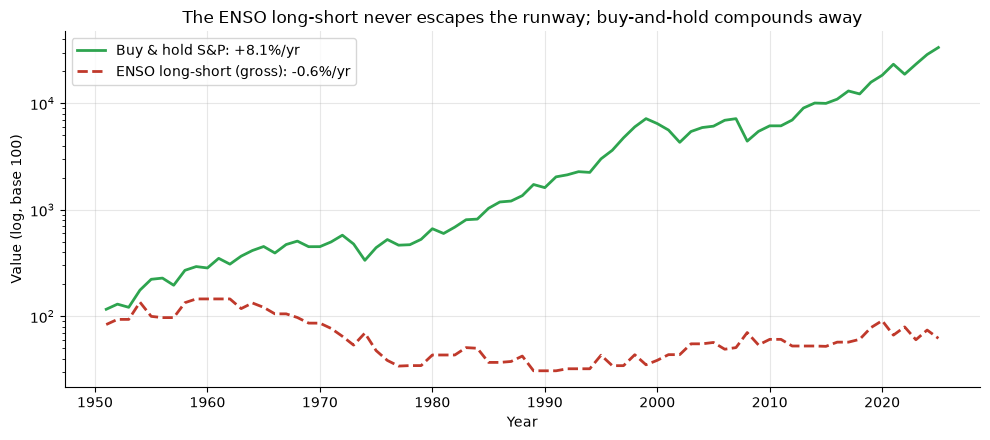

Gross -0.6%/yr | Net -0.9%/yr | Buy-hold +8.1%/yr | turnover 1.0/yr


In [8]:
if HAVE_REAL:
    bt = st.backtest(df, cost_bps_oneway=10.0, short_borrow_bps=50.0)
    gross, net, bah, to = bt['gross_ann']*100, bt['net_ann']*100, bt['buy_hold_ann']*100, bt['turnover_per_yr']
    sig = st.signal_warm_cold(df).values.astype(float)
    yrs = df['year'].values
    strat_cum = (1 + sig*df['asset_return'].values).cumprod()*100
    bah_cum = (1 + df['asset_return'].values).cumprod()*100
else:
    gross, net, bah, to = R['gross_ann'], R['net_ann'], R['buy_hold_ann'], R['turnover']
    rng4 = np.random.default_rng(99); yrs = np.arange(R['year_start'], R['year_end']+1)
    strat_cum = (1+rng4.normal(gross/100/R['n'],0.16,R['n'])).cumprod()*100
    bah_cum = (1+rng4.normal(bah/100/R['n'],0.16,R['n'])).cumprod()*100

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(yrs, bah_cum, lw=2, c=GREEN, label=f'Buy & hold S&P: {bah:+.1f}%/yr')
ax.plot(yrs, strat_cum, lw=2, c=RED, ls='--', label=f'ENSO long-short (gross): {gross:+.1f}%/yr')
ax.set_yscale('log'); ax.set_xlabel('Year'); ax.set_ylabel('Value (log, base 100)')
ax.set_title('The ENSO long-short never escapes the runway; buy-and-hold compounds away')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Gross {gross:+.1f}%/yr | Net {net:+.1f}%/yr | Buy-hold {bah:+.1f}%/yr | turnover {to:.1f}/yr')

> The long-short loses money gross and net, dominated entirely by buy-and-hold. Shorting the market on a weather forecast is the trade; it is a bad one.

## 7 - Going further -- the synthetic positive control

Does the engine detect an ENSO premium *when one exists*? Plant one and sweep it.

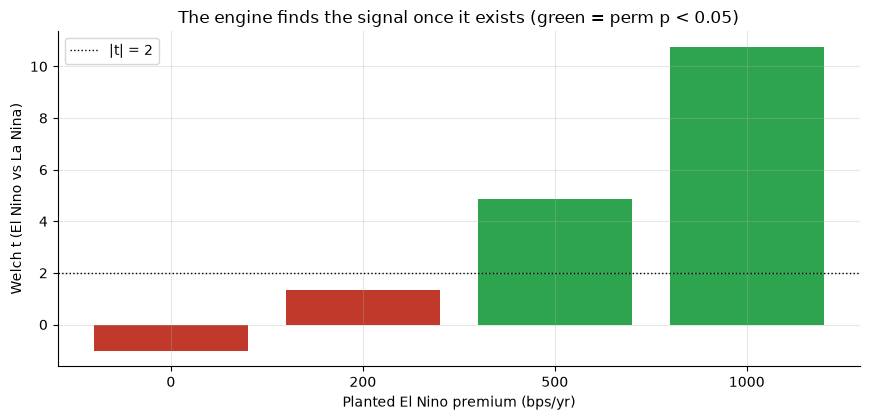

 bps  gap_pct  welch_t  perm_p
   0    -1.75   -1.035  0.3000
 200     2.25    1.326  0.1775
 500     8.25    4.867  0.0000
1000    18.25   10.768  0.0000


In [9]:
planted = [0, 200, 500, 1000]
rows = []
for bps in planted:
    ds, _ = data.synthetic_panel(n_years=600, premium_bps=float(bps), seed=281)
    ds = ds.rename(columns={'ret':'asset_return'})
    rr = st.phase_stats(ds, n_permutations=400, seed=99)
    rows.append({'bps': bps, 'gap_pct': round(rr['gap']*100,2),
                 'welch_t': rr['welch_t'], 'perm_p': rr['perm_p']})
res = pd.DataFrame(rows)
colors = [GREEN if x['perm_p']<0.05 else RED for x in rows]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar([str(x['bps']) for x in rows], [x['welch_t'] for x in rows], color=colors)
ax.axhline(2, c='k', ls=':', lw=1, label='|t| = 2')
ax.set_xlabel('Planted El Nino premium (bps/yr)'); ax.set_ylabel('Welch t (El Nino vs La Nina)')
ax.set_title('The engine finds the signal once it exists (green = perm p < 0.05)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))

The engine correctly detects a planted ENSO premium once it is large enough (>= ~500 bps/yr at n=600). The real tape -- n=75, gap +3.2pp, ~25 obs/phase -- is nowhere near the detection threshold. The verdict is a statement about the **market and the sample**, not the method.